These are the variables from the UPPAAL model
S: Susceptible

E: Exposed

I: Infected

H: Hospitalized

R: Recovered

In [19]:
import json
import pandas as pd

# Load COVID model trace (from UPPAAL .uctr export)
with open("COVID.uctr", "r") as f:
    trace = json.load(f)

# Initial variables and time
init_vars = trace["init"]["vars"]
initial_time = 0.0

# Semantic labels for model variables
state_vars = ["S", "E", "I", "H", "R"]

# Start with initial state
time_series = [{
    "time": initial_time,
    **{var: val for var, val in zip(state_vars, init_vars)}
}]

# Traverse transitions
current_time = 0.0
for transition in trace["transitions"]:
    current_time += transition["delay"]
    vars_values = transition["state"]["vars"]
    time_series.append({
        "time": current_time,
        **{var: val for var, val in zip(state_vars, vars_values)}
    })

# Create and save DataFrame
df = pd.DataFrame(time_series)
df.set_index("time", inplace=True)

# Optional: calculate additional metrics
df["Active"] = df["E"] + df["I"] + df["H"]
df["Recovered"] = df["R"]
df["Susceptible"] = df["S"]

# Save or preview
df.to_csv("covid_epidemic_timeseries.csv")

df.head(20)

,S,E,I,H,R,Active,Recovered,Susceptible
time,,,,,,,,
0.000000,9900,100,0,0,0,100,0,9900
26.764546,9900,99,1,0,0,100,0,9900
46.422759,9900,99,0,1,0,100,0,9900
56.768072,9900,99,0,0,1,99,1,9900
69.457720,9900,98,1,0,1,99,1,9900
108.127401,9900,98,0,0,2,98,2,9900
119.886811,9900,97,1,0,2,98,2,9900
137.319233,9900,96,2,0,2,98,2,9900
150.399183,9900,95,3,0,2,98,2,9900


In [27]:
print(df.info())       # Check for missing data



<class 'pandas.core.frame.DataFrame'>
Index: 404 entries, 0.0 to 25838.721959526905
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   S            404 non-null    int64
 1   E            404 non-null    int64
 2   I            404 non-null    int64
 3   H            404 non-null    int64
 4   R            404 non-null    int64
 5   Active       404 non-null    int64
 6   Recovered    404 non-null    int64
 7   Susceptible  404 non-null    int64
 8   Total        404 non-null    int64
dtypes: int64(9)
memory usage: 31.6 KB
None


In [28]:
print(df.describe())   # Get ranges and basic stats

# Check if any column has NaNs
print("Missing values:\n", df.isna().sum())

                 S           E           I           H           R  \
count   404.000000  404.000000  404.000000  404.000000  404.000000   
mean   9870.339109   58.990099    1.547030    0.836634   68.287129   
std      17.571304   22.642653    1.827625    1.000270   39.700451   
min    9838.000000   21.000000    0.000000    0.000000    0.000000   
25%    9855.000000   40.750000    0.000000    0.000000   34.000000   
50%    9872.000000   56.000000    1.000000    1.000000   70.000000   
75%    9885.250000   80.000000    2.000000    1.000000  102.250000   
max    9900.000000  100.000000   10.000000    4.000000  138.000000   

           Active   Recovered  Susceptible    Total  
count  404.000000  404.000000   404.000000    404.0  
mean    61.373762   68.287129  9870.339109  10000.0  
std     22.310384   39.700451    17.571304      0.0  
min     22.000000    0.000000  9838.000000  10000.0  
25%     42.000000   34.000000  9855.000000  10000.0  
50%     58.500000   70.000000  9872.000000  1

In [24]:
df["Total"] = df["S"] + df["E"] + df["I"] + df["H"] + df["R"]
constant_population = df["Total"].iloc[0]
max_deviation = (df["Total"] - constant_population).abs().max()

print(f"Initial Total Population: {constant_population}")
print(f"Max deviation over time: {max_deviation}")


Initial Total Population: 10000
Max deviation over time: 0


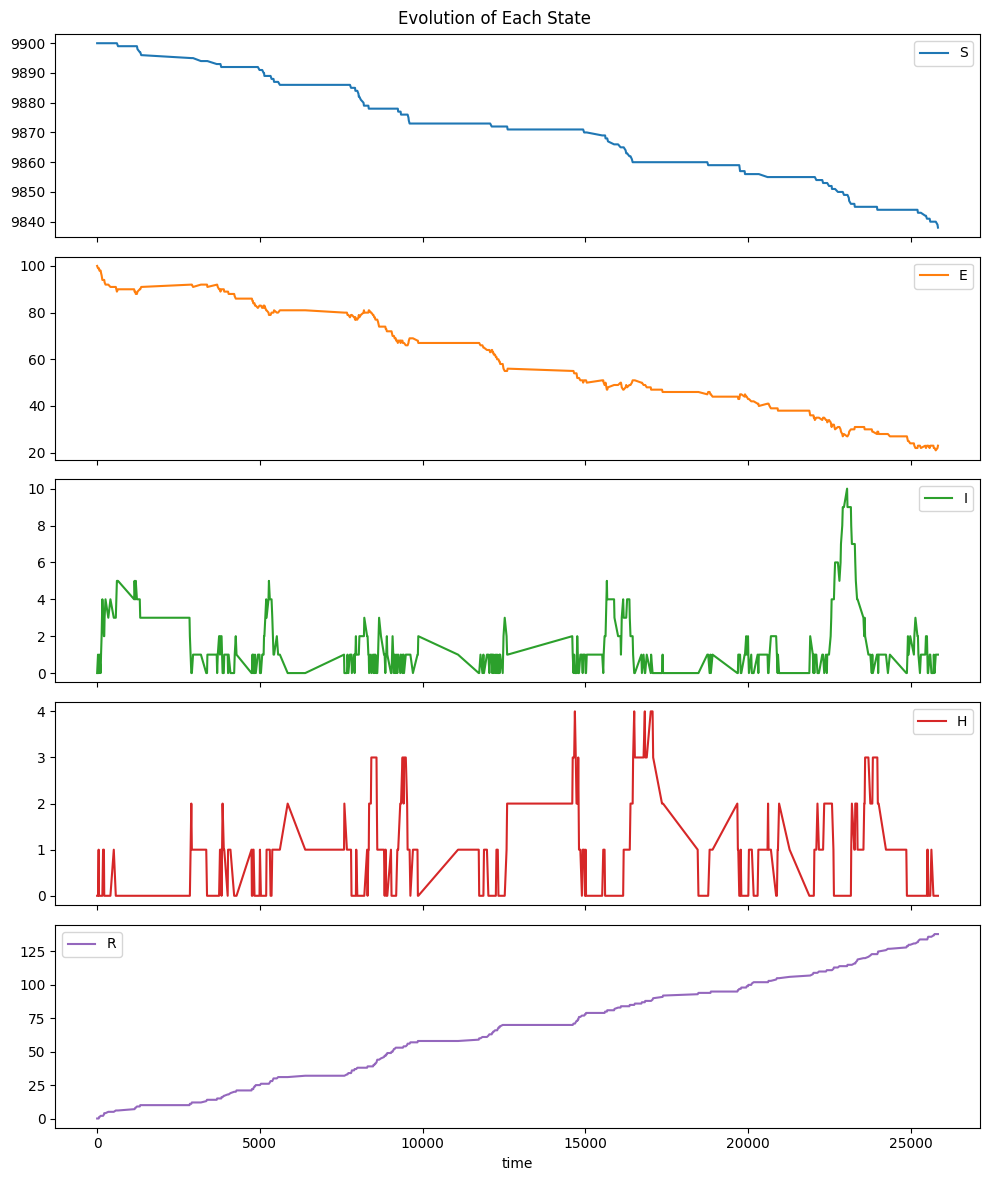

In [30]:
df[["S", "E", "I", "H", "R"]].plot(subplots=True, figsize=(10, 12), title="Evolution of Each State")
plt.tight_layout()
plt.show()
